# Load Libs 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
from pathlib import Path


# Import nexusformat
try:
    from nexusformat.nexus import nxload
    NEXUS_AVAILABLE = True
    print("nexusformat loaded successfully!")
except ImportError:
    NEXUS_AVAILABLE = False
    print("Install nexusformat: pip install nexusformat")


    

# Setting plotting style
plt.style.use('default')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
warnings.filterwarnings('ignore')

nexusformat loaded successfully!


# Load and explore the actual structure

In [2]:
filepath = "/Users/shubhamshinde/Documents/Neutron Project /Data /benzene_260_360_inc.nxspe"
filepath = Path(filepath)


if filepath.exists() and NEXUS_AVAILABLE:
    # Load the file
    data = nxload(str(filepath))
    
    
    # Get the actual entry name
    entry_name = list(data.keys())[0]
    print(f"Entry name: {entry_name}")
    print()
    

    # Access the entry
    entry = data[entry_name]
    nxspe_entry = entry
    
    print("EXPLORING STRUCTURE:")
    


    # Simple function to print structure
    def print_item(key, item, indent=0):
        indent_str = "  " * indent
        if hasattr(item, 'shape'):
            print(f"{indent_str} {key}: shape={item.shape}")
        elif hasattr(item, 'nxclass'):
            print(f"{indent_str} {key} [{item.nxclass}]")
            # Don't go too deep
            if indent < 2:  # Only show next level
                try:
                    for subkey in item.keys():
                        print_item(subkey, item[subkey], indent + 1)
                except:
                    pass





        else:
            try:
                value = item.nxvalue
                if isinstance(value, (int, float)):
                    print(f"{indent_str} {key}: {value}")
                else:
                    print(f"{indent_str} {key}")
            except:
                print(f"{indent_str} {key}")
    




    # Print main structure
    for key in entry.keys():
        print_item(key, entry[key])






else:
    print("Cannot load file!")
    nxspe_entry = None

Entry name: __MSL____PLET_benzene_260K_3.60meV_inc_rings

EXPLORING STRUCTURE:
 NXSPE_info [NXcollection]
   fixed_energy: shape=(1,)
   ki_over_kf_scaling: shape=(1,)
   psi: shape=(1,)
 data: shape=(249, 320)
 definition: shape=(1,)
 instrument [NXinstrument]
   fermi [NXfermi_chopper]
     energy: shape=(1,)
   name: shape=(1,)
   run_number: shape=(1,)
 program_name: shape=(1,)
 sample [NXsample]


#  Now extract data using the correct structure

What this does:

Sets the file path:

Defines the exact location of your .nxspe file

Converts it to a Path object for better handling

Loads the .nxspe file:

Uses nxload() to read the NeXus file

This creates a hierarchical data structure

Explores the file structure:

Finds the main entry name (the first key in the data)

In your file: It's __MSL____PLET_benzene_260K_3.60meV_inc_rings

This is important because earlier we tried data['data'] but it should be data[entry_name]['data']

Prints the structure:

Shows all groups and fields in the file

For important groups like 'data', 'instrument', 'sample', it shows their contents

Shows shapes of arrays which tells us the data dimensions

Saves the entry:

Stores the main entry in nxspe_entry for later use

In [3]:
def extract_data_from_entry(entry):

    """
    Extract data from the NeXus entry
    """

    if entry is None:
        return None
    
    print("EXTRACTING DATA...")
    
    try:
        # Access the data group
        data_group = entry['data']
        print("Found data group")
        


        # Extract intensity data
        intensity = data_group['data'].nxvalue
        print(f"Intensity data: shape = {intensity.shape}")
        print(f"{intensity.shape[0]} points in first dimension")
        print(f"{intensity.shape[1]} points in second dimension")
        


        # Extract errors
        if 'error' in data_group:
            errors = data_group['error'].nxvalue
            print(f"Error data: shape = {errors.shape}")
        else:
            errors = np.sqrt(np.abs(intensity))
            print("Estimating errors from sqrt(intensity)")
        



        # Extract energy values
        if 'energy' in data_group:
            energy_edges = data_group['energy'].nxvalue
            print(f"Energy bin edges: {len(energy_edges)} points")
            print(f"Range: {energy_edges[0]:.3f} to {energy_edges[-1]:.3f} meV")
            
            # Convert to bin centers
            energy_centers = 0.5 * (energy_edges[:-1] + energy_edges[1:])
            print(f"Energy centers: {len(energy_centers)} points")


        else:
            print("No energy data found!")
            return None
        



        # Try to get polar angles
        polar_angles = None
        if 'polar' in data_group:
            polar_angles = data_group['polar'].nxvalue
            print(f"Polar angles: {len(polar_angles)} values")
        




        # Trying to get temperature
        temperature = 260.0  # From filename
        ei = 3.60  # From filename
        




        # Trying to extract from sample group
        if 'sample' in entry and 'temperature' in entry['sample']:
            try:
                temperature = float(entry['sample/temperature'].nxvalue)
                print(f"Sample temperature: {temperature} K")
            except:
                print(f"Using temperature from filename: {temperature} K")
        


        # Try to get incident energy
        if 'instrument' in entry and 'fermi' in entry['instrument']:
            try:
                ei = float(entry['instrument/fermi/energy'].nxvalue)
                print(f"Incident energy: {ei} meV")
            except:
                print(f"Using Ei from filename: {ei} meV")
        


        # Create data dictionary
        data_dict = {'intensity': intensity,
                     'errors': errors,
                     'energy_edges': energy_edges,
                     'energy_centers': energy_centers,
                     'polar_angles': polar_angles,
                     'temperature': temperature,
                     'ei': ei,
                     'filename': filepath.name}
        
        print("\nData extraction complete!")
        return data_dict



    except Exception as e:
        print(f"Error: {e}")
        import traceback
        traceback.print_exc()
        return None



# Extract the data
if nxspe_entry is not None:
    benzene_data = extract_data_from_entry(nxspe_entry)

    
else:
    benzene_data = None
    print("No entry to extract from!")

EXTRACTING DATA...
Found data group
Intensity data: shape = (249, 320)
249 points in first dimension
320 points in second dimension
Error data: shape = (249, 320)
Energy bin edges: 321 points
Range: -2.880 to 2.880 meV
Energy centers: 320 points
Polar angles: 212 values
Incident energy: 3.6 meV

Data extraction complete!


# visualization

What this does:

Creates 3 plots in one figure:

Left plot: 2D intensity map (heatmap)

Middle plot: Single slice/spectrum

Right plot: Total spectrum (sum of all detectors)

2D Intensity Map (imshow):

Shows intensity as colors

X-axis: Energy transfer (meV)

Y-axis: Detector/index number

Color represents intensity

Why transpose? Checks if energy is first dimension and transposes if needed for correct orientation

Single Slice Plot:

Takes the middle detector/slice

Plots intensity vs energy for that one detector

Shows what a single spectrum looks like

Total Spectrum Plot:

Sums intensity across all detectors

Shows the overall energy dependence

Adds green dashed line at zero energy (elastic line)

Adds information box with:

Filename

Temperature

Incident energy

Data shape

Visualization purpose: This gives you a quick overview of your data quality and structure.

Plotting data with shape: (249, 320)
Energy range: -2.871 to 2.871 meV


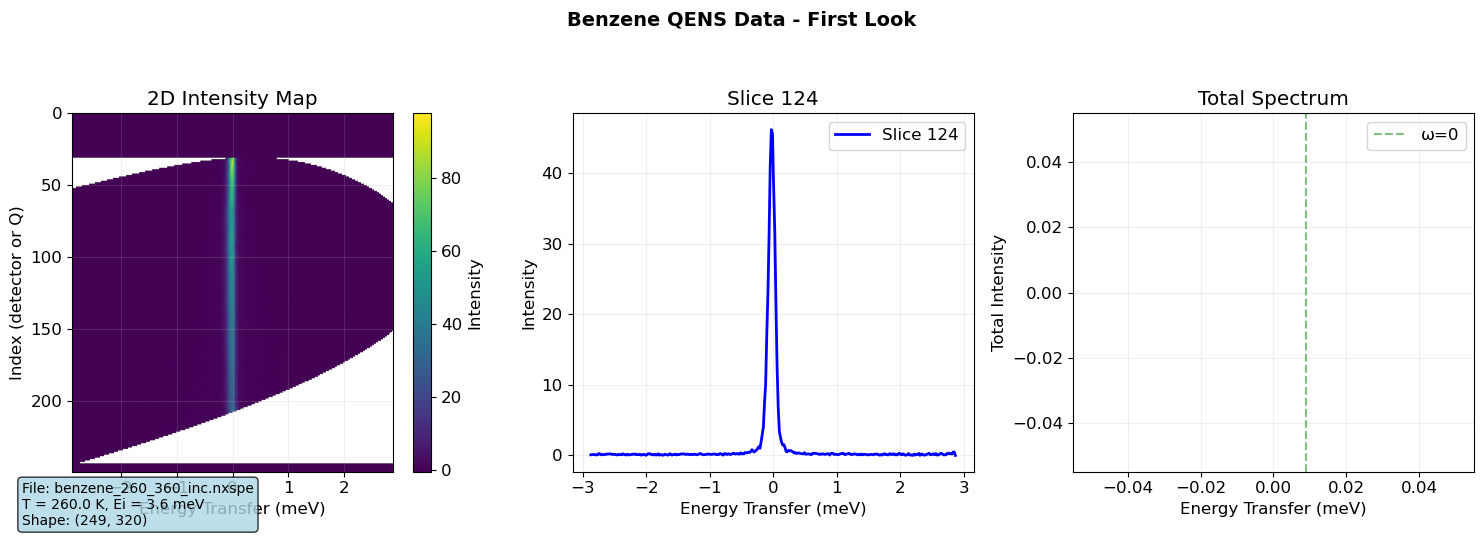

In [4]:
 def plot_simple_data(data_dict):

    """
    Create a simple visualization of the extracted data
    """

    if data_dict is None:
        print("No data to plot!")
        return
    
    intensity = data_dict['intensity']
    energy = data_dict['energy_centers']
    
    print(f"Plotting data with shape: {intensity.shape}")
    print(f"Energy range: {energy[0]:.3f} to {energy[-1]:.3f} meV")
    



    # Create figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    



    # Plot 1: 2D intensity map
    ax1 = axes[0]
    
    # Check if we need to transpose

    if intensity.shape[0] == len(energy):
        # Energy is first dimension, transpose
        plot_intensity = intensity.T
        print("⚠  Transposing intensity for plotting (energy was first dimension)")

    else:
        plot_intensity = intensity
    
    im = ax1.imshow(plot_intensity, aspect='auto',
                   extent=[energy.min(), energy.max(), plot_intensity.shape[0], 0],
                   cmap='viridis')
    plt.colorbar(im, ax=ax1, label='Intensity')
    ax1.set_xlabel('Energy Transfer (meV)')
    ax1.set_ylabel('Index (detector or Q)')
    ax1.set_title('2D Intensity Map')
    ax1.grid(True, alpha=0.2)
    






    # Plot 2: Single slice (middle one)
    ax2 = axes[1]
    middle_idx = plot_intensity.shape[0] // 2
    
    # Get the slice

    if plot_intensity.shape[0] > middle_idx:
        spectrum = plot_intensity[middle_idx, :]
        ax2.plot(energy, spectrum, 'b-', linewidth=2, 
                label=f'Slice {middle_idx}')
        ax2.set_xlabel('Energy Transfer (meV)')
        ax2.set_ylabel('Intensity')
        ax2.set_title(f'Slice {middle_idx}')
        ax2.legend()
        ax2.grid(True, alpha=0.2)

    else:
        ax2.text(0.5, 0.5, 'Cannot plot slice', 
                ha='center', va='center', transform=ax2.transAxes)
    





    # Plot 3: Total spectrum (sum over first dimension)
    ax3 = axes[2]
    total_spectrum = np.sum(plot_intensity, axis=0)
    
    ax3.plot(energy, total_spectrum, 'r-', linewidth=2)
    ax3.set_xlabel('Energy Transfer (meV)')
    ax3.set_ylabel('Total Intensity')
    ax3.set_title('Total Spectrum')
    ax3.grid(True, alpha=0.2)
    
    # Add vertical line at zero energy

    zero_idx = np.argmin(np.abs(energy))
    ax3.axvline(x=energy[zero_idx], color='g', linestyle='--', 
               alpha=0.5, label='ω=0')
    ax3.legend()
    
    # Add info text
    plt.figtext(0.02, 0.02, 
               f"File: {data_dict['filename']}\n"
               f"T = {data_dict['temperature']} K, Ei = {data_dict['ei']} meV\n"
               f"Shape: {intensity.shape}",
               fontsize=10, 
               bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.suptitle('Benzene QENS Data - First Look', 
                 fontsize=14, fontweight='bold', y=1.05)
    plt.tight_layout()
    plt.show()
    
    return fig






# Plot the data
if benzene_data is not None:
    fig = plot_simple_data(benzene_data)
else:
    print("Cannot plot - no data extracted!")

# Let's understand the data dimensions better

What this does:

Analyzes data dimensions:

Checks which dimension of intensity array corresponds to energy

In QENS, standard format is: I(detectors, energy) or I(Q, ω)

Determines correct orientation:

If energy is first dimension, transposes to make it second dimension

Why? Standard QENS analysis expects detectors/Q as first dimension, energy as second

Checks polar angles:

Compares number of polar angles with data dimensions

Helps understand what the dimensions represent

Updates data dictionary:

Adds 'intensity_corrected' with properly oriented data

Key concept: In QENS data:

First dimension: Usually detectors or Q values (spatial information)

Second dimension: Energy transfer ω (temporal/dynamic information)

Format: I[detector_index, energy_index]

In [5]:
def analyze_data_dimensions(data_dict):

    """
    Analyze and understand what the data dimensions mean
    """

    if data_dict is None:
        return
    
    intensity = data_dict['intensity']
    energy = data_dict['energy_centers']
    
    print("\nANALYZING DATA DIMENSIONS")
    
    print(f"Intensity shape: {intensity.shape}")
    print(f"Energy points: {len(energy)}")
    print()
    




    # Check which dimension corresponds to energy
    if intensity.shape[0] == len(energy):
        print("First dimension ({}) matches energy points ({})".format(
            intensity.shape[0], len(energy)))
        print("Energy is likely the FIRST dimension")
        print("Second dimension ({}) is likely detectors or Q values".format(
            intensity.shape[1]))
        
        # Transpose for QENS standard (detectors/Q first, energy second)
        transposed_intensity = intensity.T
        print(f"\nTransposing to standard QENS format: {transposed_intensity.shape}")



    elif intensity.shape[1] == len(energy):
        print("Second dimension ({}) matches energy points ({})".format(
            intensity.shape[1], len(energy)))
        print("Energy is likely the SECOND dimension (standard QENS format)")
        print("First dimension ({}) is likely detectors or Q values".format(
            intensity.shape[0]))
        transposed_intensity = intensity  # Already in correct format




    else:
        print("Energy dimension doesn't match either intensity dimension!")
        print("This is unusual - checking for issues...")
        transposed_intensity = intensity
    



    # Check if we have polar angles
    if data_dict['polar_angles'] is not None:
        polar_angles = data_dict['polar_angles']
        print(f"\nFound polar angles: {len(polar_angles)} values")
        print(f"Range: {polar_angles.min():.2f}° to {polar_angles.max():.2f}°")
        
        # Check if number of polar angles matches a dimension
        if len(polar_angles) == transposed_intensity.shape[0]:
            print("Matches first dimension - these are likely detectors")
        elif len(polar_angles) == transposed_intensity.shape[1]:
            print("Matches second dimension")
        else:
            print("Doesn't match either dimension exactly")
    



    # Update data_dict with correctly oriented data
    data_dict['intensity_corrected'] = transposed_intensity
    
    return data_dict




# Analyze dimensions
if benzene_data is not None:
    benzene_data = analyze_data_dimensions(benzene_data)


ANALYZING DATA DIMENSIONS
Intensity shape: (249, 320)
Energy points: 320

Second dimension (320) matches energy points (320)
Energy is likely the SECOND dimension (standard QENS format)
First dimension (249) is likely detectors or Q values

Found polar angles: 212 values
Range: 19.20° to 134.16°
Doesn't match either dimension exactly


# better visualization with corrected orientation

What this does:

Creates 6-panel comprehensive visualization:

Top row: Overview plots

Bottom row: Detailed analysis plots

Each subplot shows different aspect:

1️- 2D Map: I(Q,ω) - Main data visualization

2️- Multiple Slices: Compare different detectors/Q (normalized + offset for clarity)

3️ - Total Spectrum: Overall energy dependence

4️ - Elastic Line: Intensity at zero energy vs detector

5️ - Integrated Intensity: Total counts per detector

6️-  Statistics Box: Numerical summary

Key features:

Uses percentile scaling (95th) for better contrast in 2D map

Normalizes slices for fair comparison

Calculates elastic fraction (important for QENS)

Shows energy resolution (E per bin)

Why 6 plots? Each gives different insight:

2D map: Overall pattern

Slices: Individual spectra

Total spectrum: Signal quality

Elastic line: Detector efficiency variation

Integrated intensity: Detector sensitivity

Statistics: Quantitative summary



Corrected intensity shape: (249, 320)
First dimension: 249 (likely detectors/Q)
Second dimension: 320 (energy)


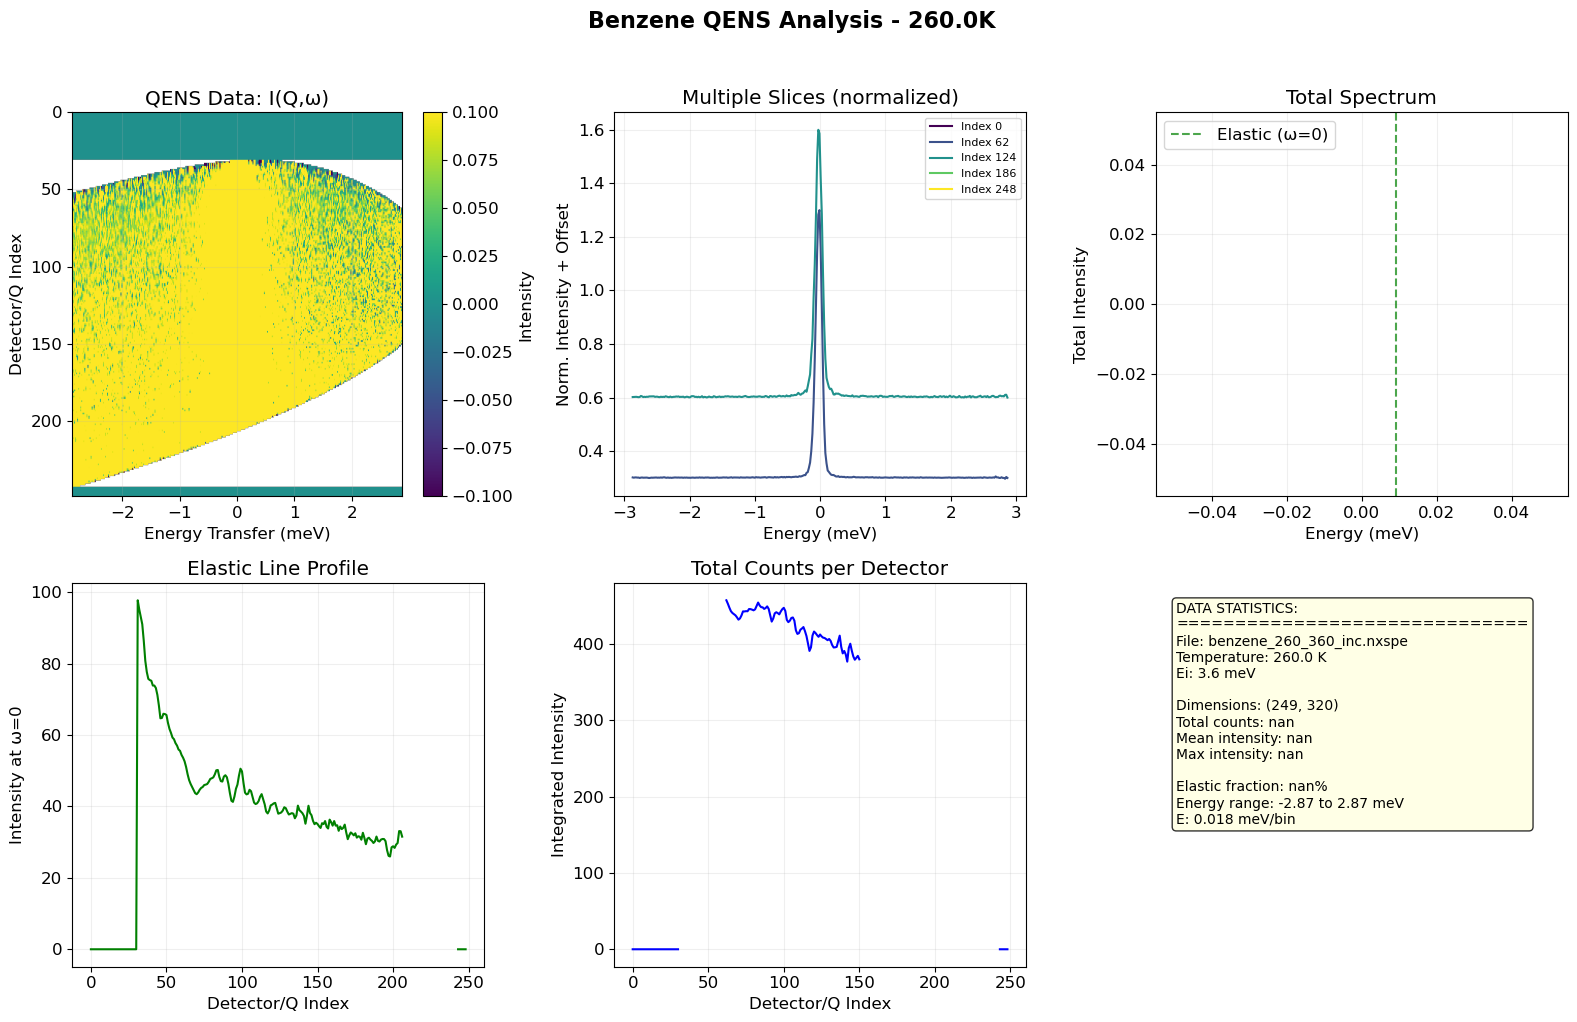

In [6]:
def plot_corrected_data(data_dict):

    """
    Plot data with correct orientation for QENS analysis
    """

    if data_dict is None or 'intensity_corrected' not in data_dict:
        print("No corrected data to plot!")
        return
    
    intensity = data_dict['intensity_corrected']
    energy = data_dict['energy_centers']
    

    print(f"Corrected intensity shape: {intensity.shape}")
    print(f"First dimension: {intensity.shape[0]} (likely detectors/Q)")
    print(f"Second dimension: {intensity.shape[1]} (energy)")
    


    fig = plt.figure(figsize=(16, 10))
    



    # Plot 1: 2D map with correct orientation
    ax1 = plt.subplot(2, 3, 1)
    
    # For QENS, we want detectors/Q on y-axis, energy on x-axis
    im = ax1.imshow(intensity, aspect='auto',
                   extent=[energy.min(), energy.max(), intensity.shape[0], 0],
                   cmap='viridis',
                   vmax=np.percentile(intensity, 95))  # Cap at 95th percentile for better contrast
    plt.colorbar(im, ax=ax1, label='Intensity')
    ax1.set_xlabel('Energy Transfer (meV)')
    ax1.set_ylabel('Detector/Q Index')
    ax1.set_title('QENS Data: I(Q,ω)')
    ax1.grid(True, alpha=0.2)
    





    # Plot 2: Several Q/detector slices
    ax2 = plt.subplot(2, 3, 2)
    
    # Select a few representative slices
    n_slices = min(5, intensity.shape[0])
    slice_indices = np.linspace(0, intensity.shape[0]-1, n_slices, dtype=int)
    
    colors = plt.cm.viridis(np.linspace(0, 1, n_slices))
    
    for i, idx in enumerate(slice_indices):
        spectrum = intensity[idx, :]
        # Normalize for better comparison
        norm_spectrum = spectrum / np.max(spectrum)
        ax2.plot(energy, norm_spectrum + i*0.3, 
                color=colors[i], linewidth=1.5,
                label=f'Index {idx}')
    
    ax2.set_xlabel('Energy (meV)')
    ax2.set_ylabel('Norm. Intensity + Offset')
    ax2.set_title('Multiple Slices (normalized)')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.2)
    





    # Plot 3: Total spectrum
    ax3 = plt.subplot(2, 3, 3)
    total_spectrum = np.sum(intensity, axis=0)
    
    ax3.plot(energy, total_spectrum, 'r-', linewidth=2)
    ax3.fill_between(energy, 0, total_spectrum, alpha=0.3, color='red')
    ax3.set_xlabel('Energy (meV)')
    ax3.set_ylabel('Total Intensity')
    ax3.set_title('Total Spectrum')
    ax3.grid(True, alpha=0.2)
    
    # Highlight elastic region
    zero_idx = np.argmin(np.abs(energy))
    ax3.axvline(x=energy[zero_idx], color='green', linestyle='--', 
               alpha=0.7, label='Elastic (ω=0)')
    ax3.legend()
    






    # Plot 4: Elastic intensity vs detector/Q
    ax4 = plt.subplot(2, 3, 4)
    elastic_intensity = intensity[:, zero_idx]
    
    ax4.plot(range(len(elastic_intensity)), elastic_intensity, 'g-', linewidth=1.5)
    ax4.set_xlabel('Detector/Q Index')
    ax4.set_ylabel('Intensity at ω=0')
    ax4.set_title('Elastic Line Profile')
    ax4.grid(True, alpha=0.2)
    







    # Plot 5: Integrated intensity vs detector/Q
    ax5 = plt.subplot(2, 3, 5)
    integrated_intensity = np.sum(intensity, axis=1)
    
    ax5.plot(range(len(integrated_intensity)), integrated_intensity, 'b-', linewidth=1.5)
    ax5.set_xlabel('Detector/Q Index')
    ax5.set_ylabel('Integrated Intensity')
    ax5.set_title('Total Counts per Detector')
    ax5.grid(True, alpha=0.2)
    







    # Plot 6: Statistics
    ax6 = plt.subplot(2, 3, 6)
    ax6.axis('off')  # Turn off axis for text box
    
    # Calculate and display statistics
    stats_text = f"DATA STATISTICS:\n"
    stats_text += "="*30 + "\n"
    stats_text += f"File: {data_dict['filename']}\n"
    stats_text += f"Temperature: {data_dict['temperature']} K\n"
    stats_text += f"Ei: {data_dict['ei']} meV\n\n"
    stats_text += f"Dimensions: {intensity.shape}\n"
    stats_text += f"Total counts: {np.sum(intensity):,.0f}\n"
    stats_text += f"Mean intensity: {np.mean(intensity):.2f}\n"
    stats_text += f"Max intensity: {np.max(intensity):.1f}\n\n"
    
    # Elastic statistics
    elastic_ratio = np.sum(elastic_intensity) / np.sum(intensity) * 100
    stats_text += f"Elastic fraction: {elastic_ratio:.1f}%\n"
    
    # Energy range
    stats_text += f"Energy range: {energy[0]:.2f} to {energy[-1]:.2f} meV\n"
    stats_text += f"E: {energy[1]-energy[0]:.3f} meV/bin"
    

    
    ax6.text(0.05, 0.95, stats_text, 
            transform=ax6.transAxes,
            fontsize=10,
            verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    plt.suptitle(f'Benzene QENS Analysis - {data_dict["temperature"]}K', 
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    
    return fig





# Plot corrected data
if benzene_data is not None:
    fig = plot_corrected_data(benzene_data)